In [212]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.cluster.hierarchy import DisjointSet

In [233]:
omega = 0.4
n = 20
T = 15

def signal(x):
    return np.sin(omega*x)

#sample signal
def sample(signal, num):
    xs = np.sort(15*np.random.rand(num))
    ys = signal(xs)+0.05*np.random.randn(num)
    return xs,ys


In [234]:
class PIECEWISE:
    def __init__(self, xb, yb):
        self.xb = xb
        self.yb = yb
        self.n = len(xb)
        if len(self.yb) != self.n: return "error: x and y mismatch"

        self.m = []
        self.b = []
        for i in range(self.n-1):
            
            self.m.append(m)
            self.b.append(b)

    def estimate(self, t):
        if t> xb[-1] or t < xb[0]:
            return "error: out of range"

    def MSE_signal(self, signal):
        total = 0
        for i in range(self.n - 1):
            m = (self.yb[i+1] - self.yb[i])/(self.xb[i+1] - self.xb[i])
            b = self.yb[i] - m*self.xb[i]
            curr, curre = quad( lambda t: (signal(t) - (m*t+b))**2, self.xb[i], self.xb[i+1])
            total+= curr
        
        return (100*total/(self.xb[-1]-self.xb[0]))

    def MSE_points(self,xs,ys):
        if xs[0] < xb[0] or xs[-1] > xb[-1]: 
            return "error: out of range"
        
        j = 0
        total = 0
        for i in range(len(xs)):
            while xs[i] > self.xb[j+1]:
                j+=1
            m = (self.yb[j+1] - self.yb[j])/(self.xb[j+1] - self.xb[j])
            b = self.yb[j] - m*self.xb[j]

            total += (yx[i] - m*xs[i] + b)**2

        return total / len(xs)
    

In [239]:
class SAMPLE:
    def __init__(self, num, signal):
        self.n = num
        self.signal = signal
        self.resample(num)
        self.xt = np.linspace(0,T,1000)
        self.yt = signal(xt)

    def resample(self,num):
        self.xs = np.sort(15*np.random.rand(num))
        self.ys = signal(self.xs)+0.05*np.random.randn(num)

    def cluster(self,indices):
        xb = [self.xs[0]]
        yb = [self.ys[0]]
        ms = []
        bs = []
        for i in range(len(indices)-1):
            I = indices[i]
            II = indices[i+1]
            XS = self.xs[I:II]
            YS = self.ys[I:II]

            OS = np.ones(len(XS))

            XMAT = np.vstack((XS,OS)).T
            [M,B] = np.linalg.solve(XMAT.T @ XMAT, XMAT.T @ np.array(YS))

            ms.append(M)
            bs.append(B)

        for i in range(len(ms)-1):
            m1 = ms[i]
            m2 = ms[i+1]
            b1 = bs[i]
            b2 = bs[i+1]

            xb.append((b2-b1)/(m1-m2))
            yb.append((m2*b1 - m1*b2)/(m2-m1))

        xb.append(self.xs[-1])
        yb.append(self.ys[-1])
            
        return PIECEWISE(xb,yb)

    def plot_signal(self):

        connected_fit = PIECEWISE(self.xs, self.ys)
        mse = connected_fit.MSE_signal(self.signal)
        
        plt.title(f'n = {self.n}, MSE = {mse}')
        # plt.scatter(self.xs,self.ys,s=5)
        plt.plot(self.xs,self.ys,color='black', linewidth=0.5)
        # plt.plot(self.xt,self.yt, '--', color = 'orange')
        plt.show()
    
    

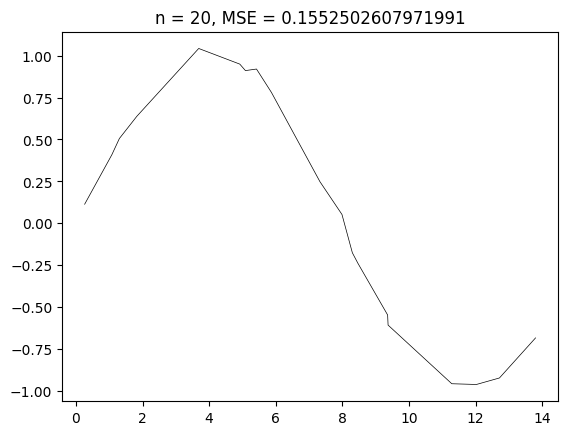

In [240]:
sample = SAMPLE(20,signal)
sample.plot_signal()
P = sample.cluster([0,5,7,11])

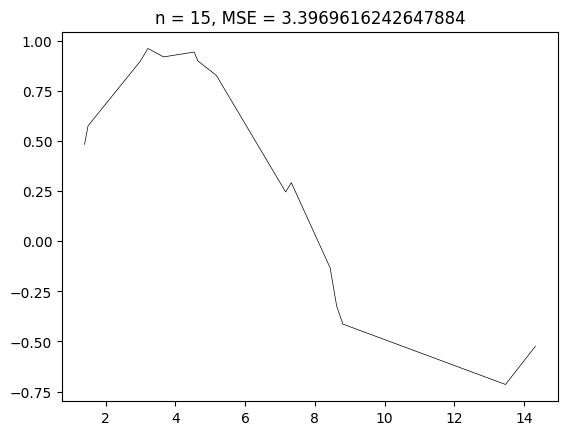

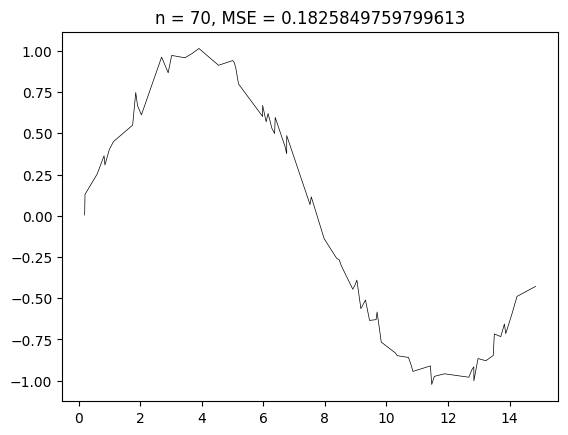

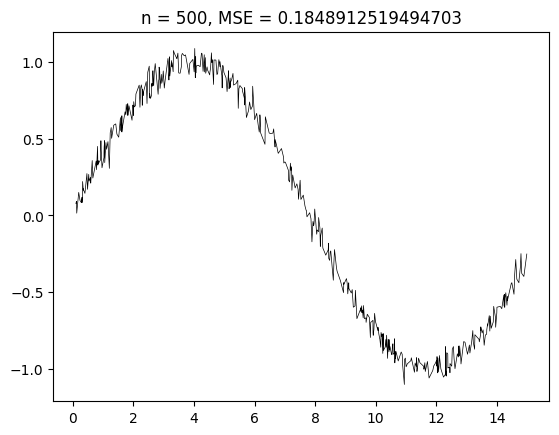

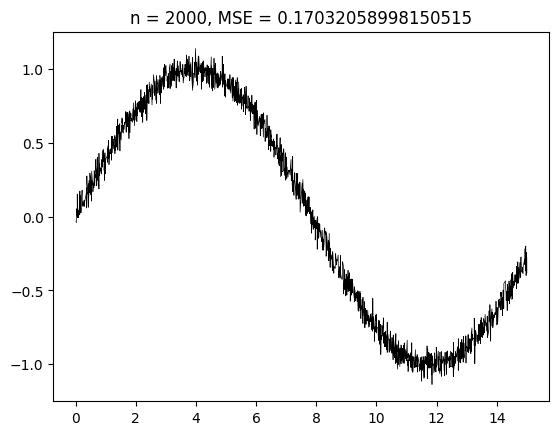

In [201]:
for num in [15,70,500,2000]:
    sample = SAMPLE(num, signal)
    sample.plot_signal()

In [209]:
def kCluster(xs, k):
    n = len(xs)

    edges = []
    for i in range(n-1):
        edges.append((i,i+1))

    edges.sort(key = lambda edge: xs[edge[1]] - xs[edge[0]])
    
    clusters = DisjointSet(range(n))

    count = n
    i = 0
    while count > k:
            
        p1 = edges[i][0]
        p2 = edges[i][1]
        
        if not clusters.connected(p1,p2):
            clusters.merge(p1,p2)
            count-=1

        i+=1

    return clusters

1
51
150
5
45
27
3
5
69
16
5
33
53
9
28


/var/folders/s3/rl7pd8bd54g2b20s8l3xmd180000gn/T/ipykernel_67835/2165909989.py:20: RankWarning: Polyfit may be poorly conditioned
  m, b = np.polyfit(xs[j:k], ys[j:k], 1)


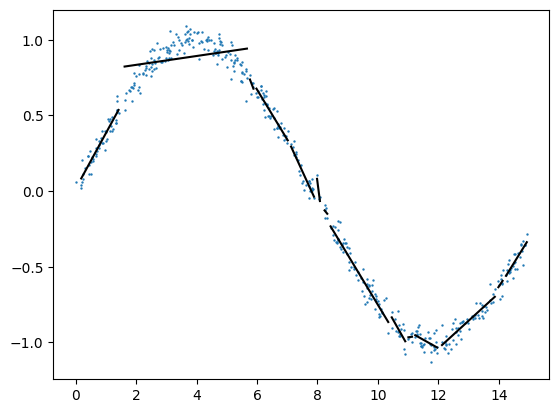

In [210]:
# using the k-clustering algorithm from homework 2

xs, ys = sample(signal, 500)
plt.scatter(xs,ys,s=0.5)
# plt.plot(xs,ys)
# plt.plot(xt,yt)

clusters = kCluster(xs, 15)
start_indices = [0]
for subset in clusters.subsets():
    print(len(subset))
    start_indices.append(start_indices[-1] + len(subset))

for i in range(len(start_indices)-1):
    j = start_indices[i]
    k = start_indices[i+1]

    xs[j:k]
    ys[j:k]
    m, b = np.polyfit(xs[j:k], ys[j:k], 1)
    line = m*xs[j:k] + b
    
    plt.plot(xs[j:k], line, color = 'black')

plt.show()

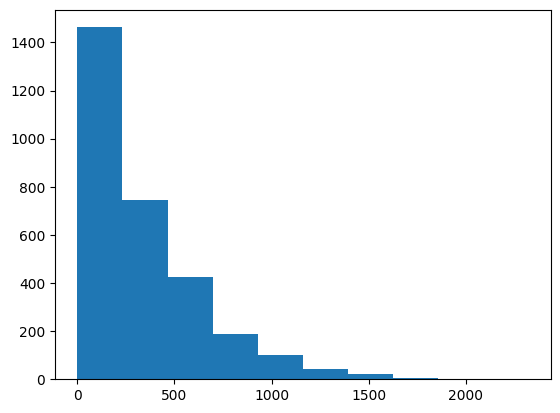

333.3333333333333 98420.35288888891


In [211]:
# this turns out to be DOODOO
# because we get a ton of tiny clusters and a handful of big ones
# see histogram of clustrer sizes below OR the example graph above
n = 5000
k = 15
trials = 200

sizes = []
for i in range(trials):
    xs, ys = sample(signal, n)
    clusters = kCluster(xs, k)
    for subset in clusters.subsets():
        sizes.append(len(subset))

plt.hist(sizes)
plt.show()
print(np.mean(sizes), np.var(sizes))

In [213]:
for i in enumerate([1,2,3]):
    print(i)

(0, 1)
(1, 2)
(2, 3)


In [226]:
xs = [1,2,3,4]
ys = [5,6,7,9]
os = np.ones(len(xs))

X = np.vstack((xs,os)).T
[m,b] = np.linalg.solve(X.T @ X,X.T @ np.array(ys))
print(m)

1.2999999999999996
